# Fotometrijska klasifikacija TDE metodom Random Forest

## Uvod

U ovom radu pravimo model masinskog ucenja koji fotometrijski identifikuje Tidal Distruption Events (TDE) trenirajuci nad simuliranim MALLORN (Many Artificial LSST Lightcurves based on Observations of Real Nuclear transients) podacima, nastalih na osnovu pravih [Zwicky Transient Facility (ZTF)](https://www.ztf.caltech.edu/) posmatarnja. 

Kvalitet modela ocenjuje se $F_1$ skorom. On je definisan kao 

#### $F_1 = \frac{2 \; Precision  \; * \; Recall}{Precision \; + \; Recall}$, $\quad$ $Precision = \frac{TP}{TP + FP}$, $\quad$  $Recall = \frac{TP}{TP + FN}$

gde su TP, FP i FN, respektivno, broj istinito pozitivnih, lazno pozitivnih i lazno negativnih.

F1 rezultat je poželjniji od jednostavne tačnosti u ovom zadatku jer je skup podataka veoma neuravnotežen, pri čemu su TDE znatno ređi od drugih klasa. Ova metrika pruža uravnoteženu meru učinka, nagrađujući modele koji postižu dobar kompromis između recall-a (detektovanja što je moguće više tačnih TDE) i precision-a (izbegavanja prekomernih lažno pozitivnih rezultata).

### Dataset

MALLORN set koji koristimo za trening i test modela, sadrzi 3043 objekta, podeljenih u 16 klasa: AGN, SN Ia, SN II, TDE, SN IIn, SN Ic, SN Ia-91T-like, SLSN-I, SN Ic-BL, SLSN-II, SN Ib, SN Ia-pec, SN IIb, SN IIP, SN Iax [02cx-like], SN Ia-91bg-like. 

Od toga, ima samo 148 TDE naspram 2895 non-TDE. Zbog toga, F1 rezultat je poželjniji od jednostavne tačnosti jer je skup podataka veoma neuravnotežen (TDE znatno ređi od drugih klasa). Ova metrika pruža uravnoteženu meru učinka, nagrađujući modele koji postižu dobar kompromis između recall-a (detektovanja što je moguće više tačnih TDE) i precision-a (izbegavanja prekomernih lažno pozitivnih rezultata).

#### Potrebni paketi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from extinction import fitzpatrick99
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score

## 1. Ucitavanje podataka

Skup podataka podeljen je u 20 približno jednakih grupa (split_01–split_20). Ova podela služi prvenstveno za organizaciju velikog broja fotometrijskih merenja. 

Za svaki objekat dostupne su dve vrste podataka: lightcurve i log podaci.

Lightcurve fajlovi sadrže pojedinačna fotometrijska merenja objekata. Svako merenje određeno je identifikatorom objekta (object_id), vremenom posmatranja (Time (MJD)), izmerenim fluksom (Flux), njegovom greškom (Flux_err) i korišćenim fotometrijskim filterom (u, g, r, i, z ili y). Jedan objekat se zato pojavljuje u više redova, jer je posmatran više puta i kroz različite filtere. Niz ovih merenja predstavlja njegovu krivu sjaja.

Log fajl sadrži po jedan red za svaki objekat i dodatne informacije o njemu, kao što su crveni pomak (Z), ekstinkcija (EBV), spektroskopska klasifikacija (SpecType) i ciljna promenljiva (target). Ciljna promenljiva ima vrednost 1 za TDE, a 0 za sve ostale tipove objekata. Kolona split određuje u kom split folderu se nalazi odgovarajuća kriva sjaja

Lightcurve i log podaci povezani su preko zajedničkog object_id. Na taj način se fotometrijska merenja svakog objekta mogu povezati sa njegovom poznatom klasifikacijom i koristiti za treniranje modela.

In [2]:
# Ucitavanje light curve podataka iz svih 20 splitova
lc_list = []
for i in range(1, 21):
    filename = f"split_{i:02d}/train_full_lightcurves.csv"
    lc_split = pd.read_csv(filename)
    lc_list.append(lc_split)

# Spajanje svih light curve tabela u jednu
lc = pd.concat(lc_list, ignore_index=True)

# Ucitavanje kompletnog train log fajla
log = pd.read_csv("train_log.csv")

# Spajanje light curve podataka sa informacijama o objektima
data = lc.merge(log, on="object_id")

# Uklanjanje merenja kojima nedostaje Flux
data = data.dropna(subset=["Flux"]).reset_index(drop=True)

# Provera
print("Broj merenja:", len(lc))
print("Broj objekata nakon spajanja:", data["object_id"].nunique())

print("\nTarget:")
print(log["target"].value_counts())

Broj merenja: 479384
Broj objekata nakon spajanja: 3043

Target:
target
0    2895
1     148
Name: count, dtype: int64


### Prikaz razlicitih tipova objekata

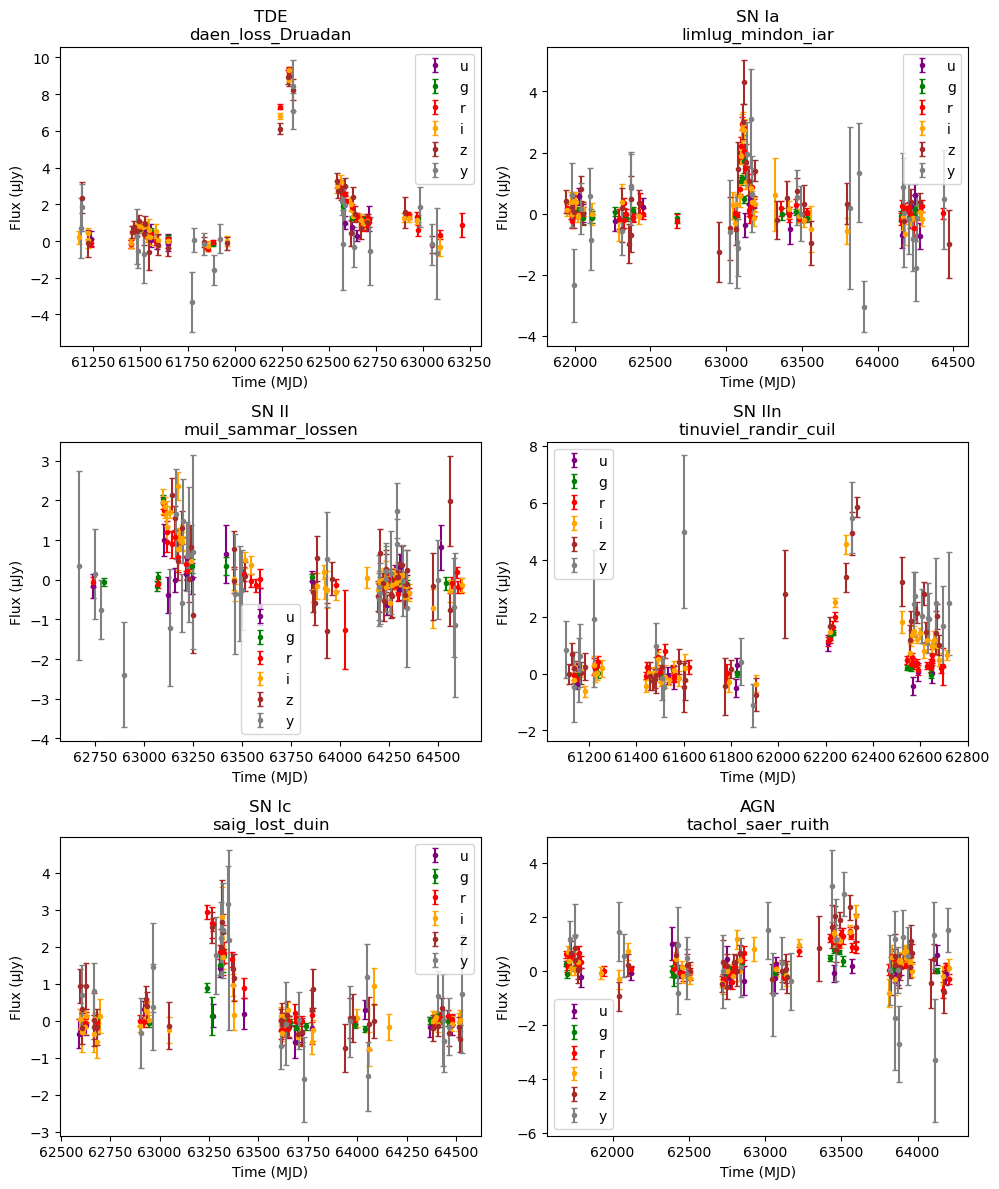

In [3]:
# Tipovi objekata koje zelimo da prikazemo
types = ["TDE", "SN Ia", "SN II", "SN IIn", "SN Ic", "AGN"]

filter_colours = { "u": "purple",  "g": "green","r": "red", "i": "orange", "z": "brown","y": "gray"}

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

axes = axes.flatten()

for ax, spec_type in zip(axes, types):

    # Nasumicno biramo jedan objekat datog tipa
    object_id = ( log[log["SpecType"] == spec_type]["object_id"] .sample(1) .iloc[0])
    obj = data[data["object_id"] == object_id]

    for filt in ["u", "g", "r", "i", "z", "y"]:

        band = (obj[obj["Filter"] == filt].sort_values("Time (MJD)")  )

        if len(band) > 0:

            ax.errorbar( band["Time (MJD)"].to_numpy(),  band["Flux"].to_numpy(),yerr=band["Flux_err"].to_numpy(),
                fmt=".",label=filt,  color=filter_colours[filt],  capsize=2  )

    ax.set_title(f"{spec_type}\n{object_id}")
    ax.set_xlabel("Time (MJD)")
    ax.set_ylabel("Flux (μJy)")
    ax.legend()

plt.tight_layout()
plt.show()

## 2. Preprocessing fotometrije - priprema podataka za dalju analizu

#### Deekstinkcija

Pre izdvajanja karakteristika iz krivih sjaja izvršena je korekcija fotometrijskih merenja za međuzvezdanu ekstinkciju.

Za svaki objekat u log fajlu data je vrednost E(B−V), koja predstavlja meru ekstinkcije duž pravca posmatranja. Korekcija je izvršena korišćenjem Fitzpatrick-ovog zakona ekstinkcije, uz standardnu vrednost $R_v = 3.1$

In [4]:
# Efektivne talasne duzine LSST filtera u Angstromima
eff_wavelength = {"u": 3641, "g": 4704, "r": 6155, "i": 7504, "z": 8695, "y": 10056}

# Funkcija koja racuna faktor korekcije za ekstinkciju
def extinction_correction(row):
    wavelength = eff_wavelength[row["Filter"]]
    A_lambda = fitzpatrick99(np.array([wavelength], dtype=float), row["EBV"] * 3.1)[0]
    correction_factor = 10**(A_lambda / 2.5)
    return correction_factor

# Racunanje faktora korekcije za svako merenje
data["extinction_factor"] = data.apply(extinction_correction,axis=1)

# De-ekstinkcija fluxa
data["Flux_corrected"] = (data["Flux"] * data["extinction_factor"])

# De-ekstinkcija greske fluxa
data["Flux_err_corrected"] = (data["Flux_err"] * data["extinction_factor"])

# Provera rezultata
print(data[["Filter", "EBV", "Flux", "Flux_corrected", "Flux_err", "Flux_err_corrected"]].head(10))

  Filter   EBV       Flux  Flux_corrected  Flux_err  Flux_err_corrected
0      z  0.11  -1.630159       -1.895577  0.365777            0.425332
1      r  0.11  10.499389       13.652524  0.253867            0.330108
2      y  0.11   5.866250        6.595811  1.559241            1.753158
3      r  0.11   3.903623        5.075944  0.376854            0.490030
4      i  0.11   5.226644        6.340941  0.516864            0.627057
5      g  0.11   0.984804        1.443179  0.109919            0.161080
6      r  0.11   1.485012        1.930985  0.181529            0.236045
7      u  0.11   0.170766        0.276268  0.551879            0.892838
8      r  0.11   1.183222        1.538563  0.208419            0.271010
9      i  0.11   0.725684        0.880396  0.533212            0.646890


### Feature extraction

Model ne koristi sva zabelezena merenja, vec mu dostavljamo tabelu sa sumiranim podacima.

Za potrebe klasifikacije, vremenske serije fotometrijskih merenja transformisane su u tabelu karakteristika, pri čemu jedan red odgovara jednom astronomskom objektu. Za svaki fotometrijski filter izdvojene su statističke i vremenske karakteristike krive sjaja, uključujući srednji, maksimalni i minimalni fluks, standardnu devijaciju, amplitudu, vreme dostizanja maksimuma, trajanje, kao i brzinu porasta i opadanja fluksa. Dodatno su uključeni crveni pomak i informacije o boji objekta. Ove karakteristike predstavljaju ulazne promenljive Random Forest klasifikatora, dok je ciljna promenljiva binarna oznaka TDE/non-TDE.

In [ ]:
# Filteri
filters = ["u", "g", "r", "i", "z", "y"]

# Ovde cuvamo features za svaki objekat
feature_rows = []

# Prolazimo kroz svaki objekat posebno
for object_id, object_data in data.groupby("object_id"):

    features = { "object_id": object_id}

    # Prolazimo kroz svaki filter posebno
    for filt in filters:

        band = object_data[object_data["Filter"] == filt].copy()

        # Sortiramo merenja po vremenu
        band = band.sort_values("Time (MJD)")

        # Broj merenja u ovom filteru
        n = len(band)
        features[f"n_{filt}"] = n

        # Ako objekat nema merenja u ovom filteru
        if n == 0:

            features[f"mean_flux_{filt}"] = np.nan
            features[f"max_flux_{filt}"] = np.nan
            features[f"min_flux_{filt}"] = np.nan
            features[f"std_flux_{filt}"] = np.nan
            features[f"amplitude_{filt}"] = np.nan

            features[f"duration_{filt}"] = np.nan
            features[f"time_to_peak_{filt}"] = np.nan
            features[f"rise_rate_{filt}"] = np.nan
            features[f"decline_rate_{filt}"] = np.nan

            continue

        # OSNOVNE FLUX KARAKTERISTIKE

        features[f"mean_flux_{filt}"] = band["Flux_corrected"].mean()
        features[f"max_flux_{filt}"] = band["Flux_corrected"].max()
        features[f"min_flux_{filt}"] = band["Flux_corrected"].min()
        features[f"std_flux_{filt}"] = band["Flux_corrected"].std()
        
        features[f"amplitude_{filt}"] = (band["Flux_corrected"].max()- band["Flux_corrected"].min())

        # VREMENSKE KARAKTERISTIKE

        # Vreme prvog i poslednjeg merenja
        first_time = band["Time (MJD)"].iloc[0]
        last_time = band["Time (MJD)"].iloc[-1]

        # Ukupno vreme tokom kog imamo posmatranja
        duration = last_time - first_time
        features[f"duration_{filt}"] = duration

        # MAKSIMUM LIGHT CURVE-A

        # Indeks reda u kome je flux maksimalan
        peak_index = band["Flux_corrected"].idxmax()

        peak_time = band.loc[peak_index, "Time (MJD)"]
        peak_flux = band.loc[peak_index, "Flux_corrected"]

        # Koliko je vremena proslo od prvog merenja do maksimuma
        time_to_peak = peak_time - first_time
        features[f"time_to_peak_{filt}"] = time_to_peak

        # RISE I DECLINE RATE

        peak_index = band["Flux_corrected"].idxmax()
        peak_time = band.loc[peak_index, "Time (MJD)"]

        # Tacke do maksimuma
        before_peak = band[band["Time (MJD)"] <= peak_time]

        # Tacke od maksimuma nadalje
        after_peak = band[band["Time (MJD)"] >= peak_time]

        # RISE RATE
        if len(before_peak) >= 2:
            rise_rate = np.polyfit(  before_peak["Time (MJD)"],before_peak["Flux_corrected"], 1)[0]
        else:
            rise_rate = np.nan

        # DECLINE RATE
        if len(after_peak) >= 2:
            decline_rate = np.polyfit( after_peak["Time (MJD)"], after_peak["Flux_corrected"], 1)[0]
        else:
            decline_rate = np.nan

        features[f"rise_rate_{filt}"] = rise_rate
        features[f"decline_rate_{filt}"] = decline_rate
    
    # Zavrsili smo svih 6 filtera za ovaj objekat
    feature_rows.append(features)

# Pretvaramo rezultate u DataFrame
features = pd.DataFrame(feature_rows)

# Dodajemo target iz log fajla
features = features.merge( log[["object_id", "Z", "target"]], on="object_id")

#### Dodajemo jos informacija: boje

In [ ]:
# Funkcija za racunanje boje iz dva fluxa
def flux_color(f1, f2):
    if pd.isna(f1) or pd.isna(f2):
        return np.nan
    if f1 <= 0 or f2 <= 0:
        return np.nan
    return -2.5 * np.log10(f1 / f2)

# Racunamo boje iz maksimalnih fluxova u susednim filterima
features["u-g"] = features.apply(lambda row: flux_color(row["max_flux_u"], row["max_flux_g"]), axis=1)
features["g-r"] = features.apply( lambda row: flux_color(row["max_flux_g"], row["max_flux_r"]), axis=1)
features["r-i"] = features.apply(lambda row: flux_color(row["max_flux_r"], row["max_flux_i"]),axis=1)
features["i-z"] = features.apply( lambda row: flux_color(row["max_flux_i"], row["max_flux_z"]), axis=1)
features["z-y"] = features.apply( lambda row: flux_color(row["max_flux_z"], row["max_flux_y"]), axis=1)

# Pogledamo rezultat
print(features.head().round(3))

### Pravljenje X i Y

Nakon izdvajanja karakteristika, podaci su razdvojeni na matricu ulaznih promenljivih X i ciljnu promenljivu y. Matrica X sadrži numeričke karakteristike izvedene iz fotometrijskih krivih sjaja, kao i dodatne karakteristike poput crvenog pomaka i boje objekta. Vektor y sadrži binarnu klasifikaciju objekata, pri čemu vrednost 1 označava TDE, a vrednost 0 sve ostale klase. Matrica X predstavlja podatke na osnovu kojih se model trenira, dok y predstavlja poznate odgovore sa kojima model tokom treniranja povezuje odgovarajuće karakteristike.

In [ ]:
# X = ulazne karakteristike za model
X = features.drop(columns=["object_id", "target"])

# y = ono sto model treba da predvidi
y = features["target"]

#### Delimo X i Y setove na train i test

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=50, stratify=y)

print("TDE/non-TDE u training skupu:")
print(y_train.value_counts())

print("\nTDE/non-TDE u validation skupu:")
print(y_val.value_counts())

### Nan vrednosti

Desava se da se maksimum odigravana samom pocetku ili kaju posmatranja. Zbog toga se javlja NaN vrednost umesto rise rate ili decline rate. Te vrednosti menjamo medijanom. Ako bismo menjali mean-om, verovatno bismo dobili previsoku vrednost. 

In [ ]:
# Imputer koji nedostajuce vrednosti zamenjuje medijanom
imputer = SimpleImputer(strategy="median")

# Medijane racunamo SAMO na training podacima
X_train_imputed = imputer.fit_transform(X_train)

# Na validation podatke primenjujemo iste medijane
X_val_imputed = imputer.transform(X_val)

# Vracamo rezultate u DataFrame da sacuvamo imena kolona
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)

X_val = pd.DataFrame(X_val_imputed, columns=X_val.columns, index=X_val.index)

## 3. Random Forest - pet razlicitih podela na train i test setove

Za procenu uspešnosti modela korišćena je 5-fold stratifikovana unakrsna validacija (5-fold stratified cross-validation). Skup od 3043 objekta podeljen je na pet približno jednakih delova, odnosno foldova. U svakoj iteraciji četiri folda koriste se za treniranje modela, dok se preostali fold koristi za validaciju. Postupak se ponavlja pet puta, tako da se svaki objekat jednom nalazi u validacionom skupu.

Korišćena je stratifikovana podela kako bi u svakom foldu bio približno očuvan odnos TDE i non-TDE objekata, što je posebno značajno zbog velike neuravnoteženosti klasa u ovom skupu podataka.

In [ ]:
# 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = []
precision_scores = []
recall_scores = []
best_thresholds = []

for fold, (train_index, val_index) in enumerate(skf.split(X, y), start=1):

    # Podaci za ovaj fold
    X_train_cv = X.iloc[train_index]
    X_val_cv = X.iloc[val_index]

    y_train_cv = y.iloc[train_index]
    y_val_cv = y.iloc[val_index]


    # POPUNJAVANJE NaN VREDNOSTI
    imputer = SimpleImputer(strategy="median")

    X_train_cv = imputer.fit_transform(X_train_cv)
    X_val_cv = imputer.transform(X_val_cv)

    # RANDOM FOREST
    model_cv = RandomForestClassifier(n_estimators=200,class_weight="balanced", random_state=42)   
    model_cv.fit(X_train_cv, y_train_cv)

    # Verovatnoca za TDE klasu
    y_prob_cv = model_cv.predict_proba(X_val_cv)[:, 1]

    # TRAZENJE NAJBOLJEG THRESHOLD-a
    thresholds = np.arange(0.01, 0.51, 0.01)

    best_threshold = 0
    best_f1 = 0

    for threshold in thresholds:

        y_pred_cv = (y_prob_cv >= threshold).astype(int)

        score = f1_score(y_val_cv, y_pred_cv)

        if score > best_f1:
            best_f1 = score
            best_threshold = threshold


    # Finalna predikcija za ovaj fold
    y_pred_cv = (y_prob_cv >= best_threshold).astype(int)

    precision = precision_score(y_val_cv, y_pred_cv)
    recall = recall_score(y_val_cv, y_pred_cv)

    # Cuvamo rezultate
    f1_scores.append(best_f1)
    precision_scores.append(precision)
    recall_scores.append(recall)
    best_thresholds.append(best_threshold)


    print(f"Fold {fold}")
    print(f"Threshold: {best_threshold:.2f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1: {best_f1:.3f}")
    print()

# PROSECNI REZULTATI
print("Prosecan precision:", round(np.mean(precision_scores), 3))
print("Prosecan recall:", round(np.mean(recall_scores), 3))
print("Prosecan F1:", round(np.mean(f1_scores), 3))
print("Standardna devijacija F1:", round(np.std(f1_scores), 3))

## 4. Zakljucak

Uspešnost klasifikatora procenjena je pomoću petostruke stratifikovane unakrsne validacije. Dobijen je prosečan F1 skor od približno 0.395, uz standardnu devijaciju od približno 0.056. Rezultati pokazuju da je moguće razlikovati TDE od ostalih klasa koristeći samo informacije izvedene iz fotometrijskih posmatranja, ali i da klasifikacija predstavlja težak problem, između ostalog zbog izrazite neuravnoteženosti skupa podataka, u kojem TDE objekti čine mali deo ukupnog broja objekata.

Ispitivanje različitih karakteristika pokazalo je da složeniji opis porasta i opadanja krive sjaja može poboljšati klasifikaciju, dok dodavanje većeg broja karakteristika ne dovodi nužno do boljeg rezultata. Rad takođe pokazuje značaj pravilnog izbora karakteristika, načina validacije i odgovarajućih mera uspešnosti pri primeni metoda mašinskog učenja na astronomske podatke.

Cilj rada nije bio postizanje maksimalne moguće tačnosti klasifikacije, već upoznavanje sa osnovnim postupkom primene mašinskog učenja na realne fotometrijske podatke — od njihove obrade i formiranja ulaznih karakteristika do treniranja i statističke evaluacije klasifikacionog modela.